préparation de l'environnement

installation seaborn, 

In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [8]:
df =pd.read_csv(r"C:\Users\DELL\OneDrive\Documents\odc\03-python_pour_ML_et_IA\atelier_seaborn_iot\data\mesures_capteurs.csv")

In [9]:
df.head

<bound method NDFrame.head of     id_mesure           date_heure id_capteur batiment  temperature  humidite  \
0       M0413  2026-01-22 04:00:00       C005     B002        25.46     58.06   
1       M0290  2026-01-17 01:00:00       C002     B001        24.00     79.73   
2       M0077  2026-01-08 04:00:00       C005     B002        25.82     54.47   
3       M0079  2026-01-08 06:00:00       C007     B003        28.23     69.39   
4       M0183  2026-01-12 14:00:00       C003     B001        20.58     53.80   
..        ...                  ...        ...      ...          ...       ...   
600     M0072  2026-01-07 23:00:00       C012     B004        23.67     60.28   
601     M0107  2026-01-09 10:00:00       C011     B004        24.34     61.42   
602     M0271  2026-01-16 06:00:00       C007     B003        23.73     63.49   
603     M0436  2026-01-23 03:00:00       C004     B002        24.83     79.77   
604     M0103  2026-01-09 06:00:00       C007     B003        17.02     52.04  

# partie 1 Distribution d'une variable avec histplot()
1) Afficher la distribution des températures
2) Autour de quelle valeur les températures sont concentrées ?
3) La distribution semble-t-elle symétrique ?
4) Existe-t-il des valeurs extrêmes ?
5) Modifier le nombre de classes
6) Afficher la distribution des températures par bâtiment


1) afficher la distribution des temperatures

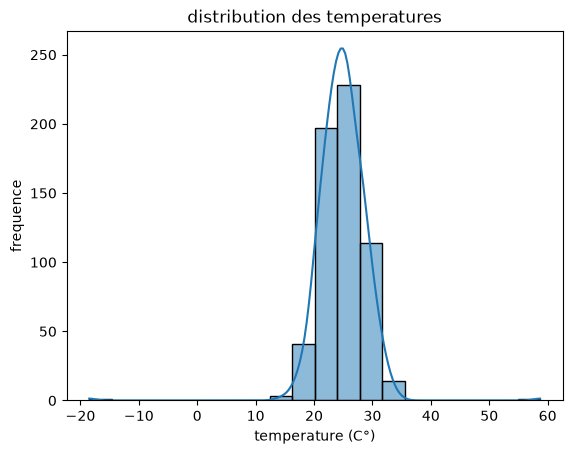

In [35]:
sns.histplot(data=df, x="temperature", bins=20, kde=True)
plt.title("distribution des temperatures")
plt.xlabel("temperature (C°)")
plt.ylabel("frequence")
plt.show()


2) Autour de quelle valeur les températures sont concentrées ?

Moyenne : 24.88 °C
Médiane : 24.86 °C


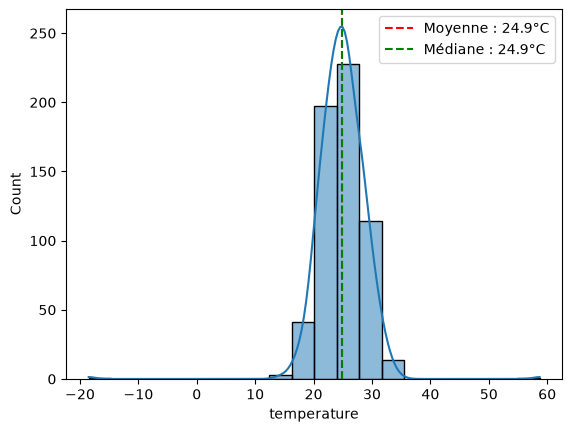

In [36]:
mean_temp = df["temperature"].mean()
median_temp = df["temperature"].median()
print(f"Moyenne : {mean_temp:.2f} °C")
print(f"Médiane : {median_temp:.2f} °C")

sns.histplot(data=df, x="temperature", bins=20, kde=True)
plt.axvline(mean_temp, color="red", linestyle="--", label=f"Moyenne : {mean_temp:.1f}°C")
plt.axvline(median_temp, color="green", linestyle="--", label=f"Médiane : {median_temp:.1f}°C")
plt.legend()
plt.show()

3) La distribution semble-t-elle symétrique ?

In [37]:
skewness = df["temperature"].skew()
print(f"Skewness : {skewness:.3f}")

Skewness : -1.047


4) Existe-t-il des valeurs extrêmes ?

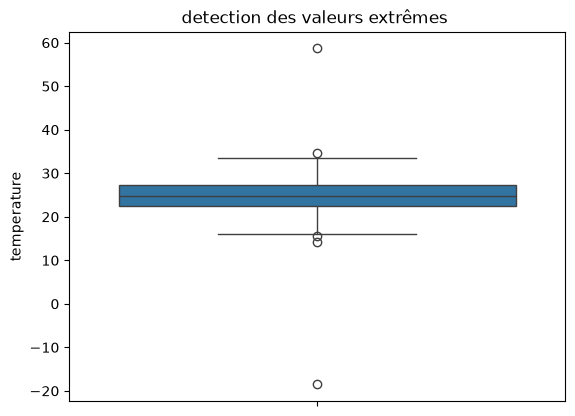

In [38]:
sns.boxplot(data=df, y="temperature")
plt.title("detection des valeurs extrêmes ")
plt.show()

il existe des valeurs extrêmes

5) Modifier le nombre de classes

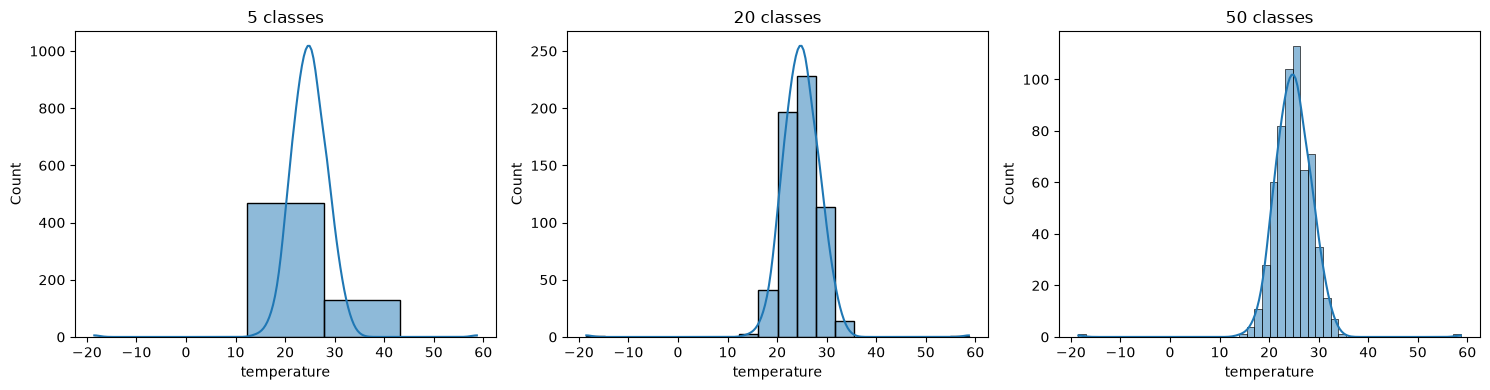

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, n_bins in zip(axes, [5, 20, 50]):
    sns.histplot(data=df, x="temperature", bins=n_bins, kde=True, ax=ax)
    ax.set_title(f"{n_bins} classes")
plt.tight_layout()
plt.show()

6) Afficher la distribution des températures par bâtiment


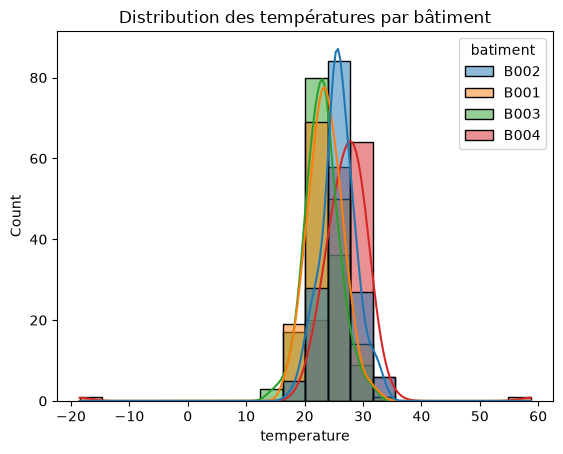

In [40]:
sns.histplot(data=df, x="temperature", hue="batiment", bins=20, kde=True)
plt.title("Distribution des températures par bâtiment")
plt.show()

Partie 2 – Distribution d'une variable avec kdeplot()
1) Afficher la distribution des températures
2) Afficher la distribution des températures par bâtiment

1) Afficher la distribution des températures

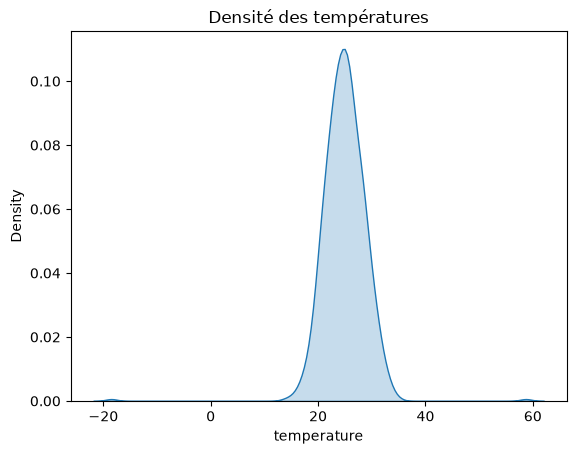

In [41]:
sns.kdeplot(data=df, x="temperature", fill=True)
plt.title("Densité des températures")
plt.show()

2) Afficher la distribution des températures par bâtiment

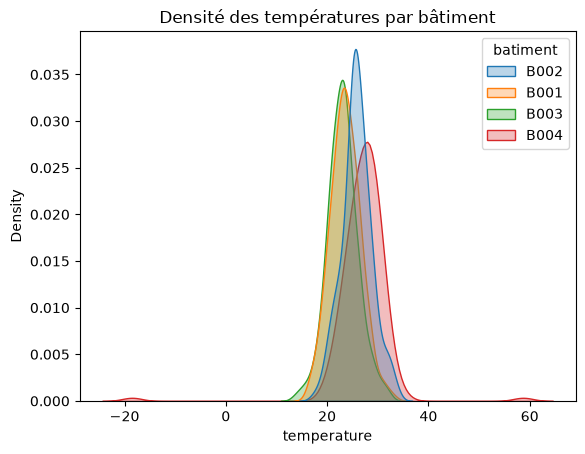

In [42]:
sns.kdeplot(data=df, x="temperature", hue="batiment", fill=True, alpha=0.3)
plt.title("Densité des températures par bâtiment")
plt.show()

Partie 3 – Distribution d'une variable avec boxplot()
1) Afficher la distribution des températures
2) Afficher la distribution des températures par bâtiment
3) Pour chaque bâtiment,
a) quelle est la médiane ?
2/2
b) quelle est la dispersion ?
c) les valeurs extrêmes
4) quels bâtiments ont les valeurs les plus extrêmes ?

1) Afficher la distribution des températures

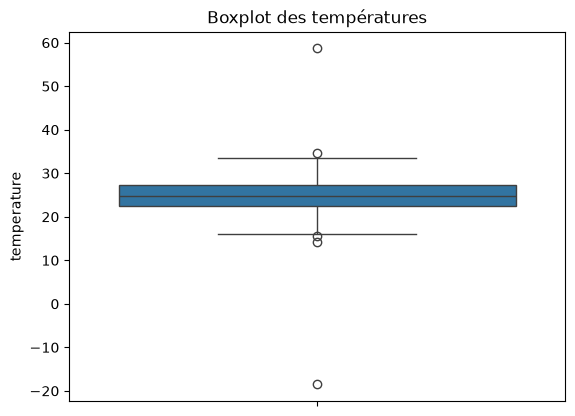

In [43]:
sns.boxplot(data=df, y="temperature")
plt.title("Boxplot des températures")
plt.show()

2) Afficher la distribution des températures par bâtiment

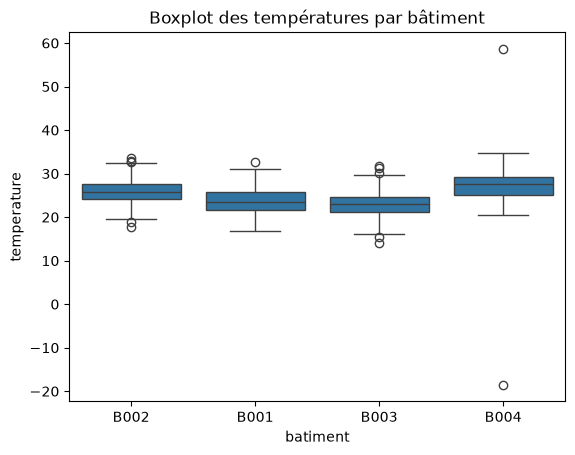

In [44]:
sns.boxplot(data=df, x="batiment", y="temperature")
plt.title("Boxplot des températures par bâtiment")
plt.show()

3) Pour chaque bâtiment,médiane,dispertion et valeurs extrêmes

In [45]:
stats_par_batiment = df.groupby("batiment")["temperature"].agg(
    mediane="median",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
)
stats_par_batiment["dispersion_iqr"] = stats_par_batiment["q3"] - stats_par_batiment["q1"]
stats_par_batiment

,mediane,q1,q3,dispersion_iqr
batiment,,,,
B001,23.540,21.6100,25.6700,4.0600
B002,25.670,24.2675,27.5300,3.2625
B003,23.045,21.0825,24.5950,3.5125
B004,27.535,25.1750,29.2825,4.1075


In [46]:
def compter_extremes(groupe):
    Q1 = groupe.quantile(0.25)
    Q3 = groupe.quantile(0.75)
    IQR = Q3 - Q1
    bas, haut = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return ((groupe < bas) | (groupe > haut)).sum()

extremes_par_batiment = df.groupby("batiment")["temperature"].apply(compter_extremes)
extremes_par_batiment

batiment
B001    1
B002    5
B003    5
B004    2
Name: temperature, dtype: int64

4) quels bâtiments ont les valeurs les plus extrêmes ?

In [47]:
print(extremes_par_batiment.idxmax(), extremes_par_batiment.max())

B002 5


Partie 4 – Distribution d'une variable avec violinplot()
1) Afficher la distribution des températures
2) Afficher la distribution des températures par bâtiment
3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box
plot ?

1) Afficher la distribution des températures

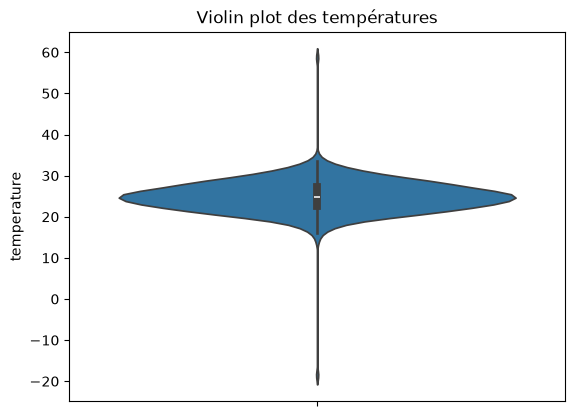

In [48]:
sns.violinplot(data=df, y="temperature")
plt.title("Violin plot des températures")
plt.show()



2) Afficher la distribution des températures par bâtiment

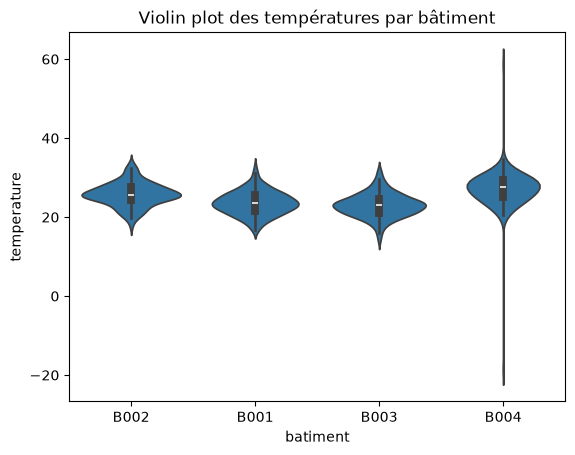

In [49]:
sns.violinplot(data=df, x="batiment", y="temperature")
plt.title("Violin plot des températures par bâtiment")
plt.show()

3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box
plot ?

Info supplémentaire vs boxplot : le violin plot montre la forme de la distribution (concentration en un ou plusieurs pics, distribution bimodale...), ce que le boxplot seul ne montre pas.

Partie 5 – Comptage des catégories avec countplot()
1) Afficher le nombre de mesures par état
2) Afficher le nombre de mesures par bâtiment
3) Afficher les états des capteurs par bâtiment pour identifier
a) le bâtiment ayant le plus de mesures en état OK ;
b) celui ayant le plus de mesures en ALERTE ;
c) celui ayant le plus de mesures en ERREUR.

1) Afficher le nombre de mesures par état

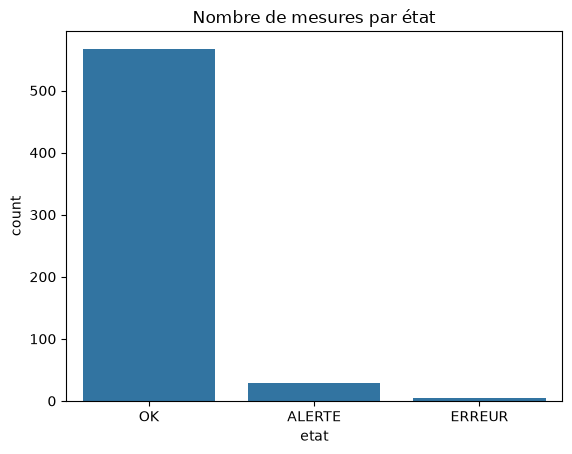

In [51]:
sns.countplot(data=df, x="etat")
plt.title("Nombre de mesures par état")
plt.show()



2) Afficher le nombre de mesures par bâtiment

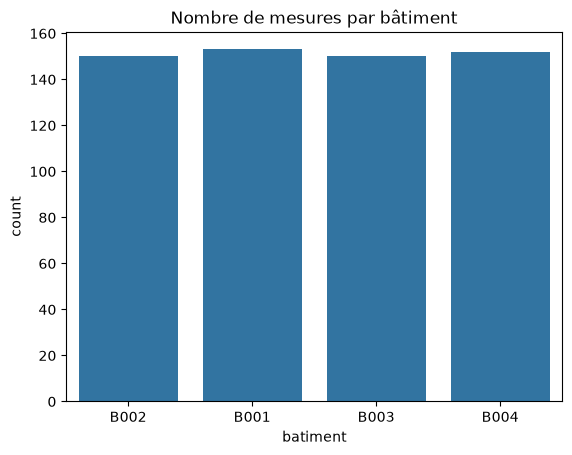

In [52]:
sns.countplot(data=df, x="batiment")
plt.title("Nombre de mesures par bâtiment")
plt.show()

3) Afficher les états des capteurs par bâtiment pour identifier

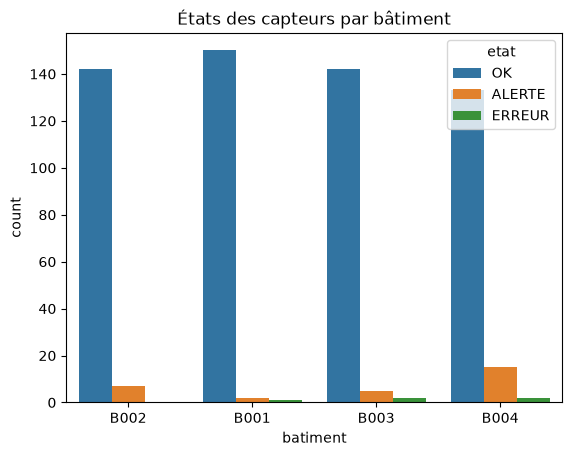

In [53]:
sns.countplot(data=df, x="batiment", hue="etat")
plt.title("États des capteurs par bâtiment")
plt.show()

In [54]:
tableau_croise = pd.crosstab(df["batiment"], df["etat"])
tableau_croise
print("a) Plus de OK :", tableau_croise["OK"].idxmax())
print("b) Plus d'ALERTE :", tableau_croise["ALERTE"].idxmax())
print("c) Plus d'ERREUR :", tableau_croise["ERREUR"].idxmax())

a) Plus de OK : B001
b) Plus d'ALERTE : B004
c) Plus d'ERREUR : B003


Partie 6 – Relation entre deux variables avec scatterplot()
1) Etudier graphiquement la relation entre température et consommation
2) Etudier graphiquement la relation entre température et consommation par bâtiment
3) Modifier la taille des points

1) Etudier graphiquement la relation entre température et consommation